# Mandat no 2 - Statistiques descriptives et inférence statistique

## i) Extraction des statistiques descriptives

Objectif : calculer les statistiques descriptives des temps de jeu (en minutes) à partir de `TempsDeJeu.txt` et afficher les résultats dans l’ordre demandé :
- moyenne échantillonnale,
- médiane,
- mode,
- écart-type,
- minimum,
- maximum,
- étendue.

Le code lit les 100 observations, puis en extrait les principales variables qui seront utilisées dans les sections suivantes.

In [752]:
# Statistiques descriptives et inférence statistique
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

temps_de_jeu = []
with open("TempsDeJeu.txt", "r", encoding="utf-8") as f:
    temps_de_jeu = np.array(
        [int(float(ligne.strip())) for ligne in f]
    )
    
moyenne = np.mean(temps_de_jeu)
mediane = np.median(temps_de_jeu)
ecart_type = np.std(temps_de_jeu)
mode = np.bincount(temps_de_jeu).argmax()
minimum = np.min(temps_de_jeu)
maximum = np.max(temps_de_jeu)
etendue = maximum - minimum

print(f"Moyenne\t\t: {moyenne}")
print(f"Médiane\t\t: {mediane}")
print(f"Écart-type\t: {ecart_type:.2f}")
print(f"Mode\t\t: {mode}")
print(f"Minimum\t\t: {minimum}")
print(f"Maximum\t\t: {maximum}")
print(f"Étendue\t\t: {etendue}")

Moyenne		: 280.58
Médiane		: 279.0
Écart-type	: 50.12
Mode		: 253
Minimum		: 148
Maximum		: 382
Étendue		: 234


## ii) Construction de l’histogramme et du tableau des classes

Objectif :
- déterminer un nombre de classes (`nb_bins`) avec la règle de la racine carrée,
- construire l’histogramme,
- produire le tableau des classes (bornes, centres, fréquences, fréquences relatives et cumulées).

Tableau des classes
| Classe	| Limites	| centres	| Fréquences	| Fréquences relatives	| Fréquences cumulées	|
| 1		| [-inf, 172[	| 159.5		| 2		| 0.02			| 0.02			|
-----------------------------------------------------------------------------------------------------------------
| 2		| [172, 196[	| 183.5		| 3		| 0.03			| 0.05			|
-----------------------------------------------------------------------------------------------------------------
| 3		| [196, 220[	| 207.5		| 6		| 0.06			| 0.11			|
-----------------------------------------------------------------------------------------------------------------
| 4		| [220, 244[	| 231.5		| 8		| 0.08			| 0.19			|
-----------------------------------------------------------------------------------------------------------------
| 5		| [244, 268[	| 255.5		| 21		| 0.21			| 0.40			|
-----------------------------------------------------------------------------------------------------------------
| 6		| [268, 292[	| 279.5		| 22		| 0.22			| 0.62			|
------

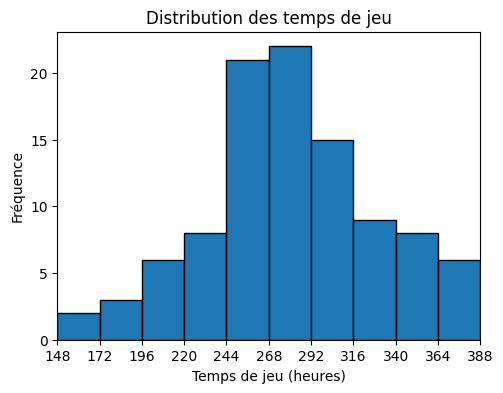

In [753]:
nb_bins = np.sqrt(len(temps_de_jeu)).astype(int)
bin_width = etendue // nb_bins + 1
histogram_max = bin_width * nb_bins + minimum + 1

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(temps_de_jeu, bins=np.arange(minimum, histogram_max, bin_width), edgecolor="black")
plt.xticks(range(minimum, histogram_max, bin_width))
plt.title("Distribution des temps de jeu")
plt.xlabel("Temps de jeu (heures)")
plt.xlim(minimum, histogram_max - 1)
plt.ylabel("Fréquence")

print("Tableau des classes")
print("="*113)
print("| Classe\t| Limites\t| centres\t| Fréquences\t| Fréquences relatives\t| Fréquences cumulées\t|")
print("="*113)

classes = []
for i in range(nb_bins):
    classe_min = minimum + i * bin_width
    classe_max = classe_min + bin_width - 1
    centre = (classe_min + classe_max) / 2
    frequence = np.sum((temps_de_jeu >= classe_min) & (temps_de_jeu <= classe_max))
    frequence_relative = frequence / len(temps_de_jeu)
    frequence_cumulee = np.sum((temps_de_jeu <= classe_max)) / len(temps_de_jeu)
    classes.append(frequence)
    if classe_max == minimum + nb_bins * bin_width - 1:
        classe_max = np.inf
    if classe_min == minimum:
        classe_min = -np.inf
    print(f"| {i+1}\t\t| [{classe_min}, {classe_max+1}[\t| {centre}\t\t| {frequence}\t\t| {frequence_relative:.2f}\t\t\t| {frequence_cumulee:.2f}\t\t\t|")
    print("-"*113)
    

## iii) Vérification de la normalité (test d’ajustement)

Objectif : vérifier quantitativement si les données peuvent être modélisées par une loi normale.

Le code :
- calcule les probabilités théoriques par classe avec la loi normale ($\mu=\bar{x}$, $\sigma=s$),
- convertit ces probabilités en effectifs attendus,
- ajuste les classes pour respecter la condition d’effectif attendu minimal,
- calcule la statistique du $\chi^2$ et la compare à une valeur critique.

Il est important de noter que le nombre de groupes a été réduit à 7 pour garantir un effectif minimal de 5 par classe.

In [ ]:
alpha = 0.05 # significance

# Bornes pour map les probabilité entre eux
bornes = minimum + np.arange(nb_bins + 1) * bin_width

# Probabilité de chaque intervalle
probabilites = (
    stats.norm.cdf(bornes[1:], loc=moyenne, scale=ecart_type)
    - stats.norm.cdf(bornes[:-1], loc=moyenne, scale=ecart_type)
)

# Conversion en effectifs attendus par classe
classes_normales = (probabilites * 100).tolist()

# on ajuste les classes pour avoir un minimum de 5
classes_ajuste_normale = [float(np.sum(classes_normales[0:3]))] + classes_normales[3:-2] + [float(np.sum(classes_normales[-2:]))]
classes_ajuste = [float(np.sum(classes[0:3]))] + classes[3:-2] + [float(np.sum(classes[-2:]))]

ki2 = 0
for i in range(len(classes_ajuste)):
    ki2 += (classes_ajuste[i] - classes_ajuste_normale[i]) ** 2 / classes_ajuste_normale[i]
df = len(classes_ajuste) - 1

print(f"Degré de liberté (df) = {df}")
valeur_critique = 12.59 # valeur tabulée du khi2 pour df = 6 (n - 1 pour ajusté) et alpha = 0.05
print(f"Valeur critique pour alpha={alpha} : {valeur_critique:.2f}")
print(f"Statistique du khi2: {ki2:.2f}")

print("Tableau des classes ajustées")
print("=" * 73)
print("| i\t| Intervalle\t| Oi (observé)\t| Ei (normal)\t| (Oi-Ei)^2/Ei\t|")
print("=" * 73)

intervalles = [f"[-inf, {bornes[3]}["]
intervalles += [f"[{bornes[k]}, {bornes[k+1]}[" for k in range(3, len(bornes) - 3)]
intervalles += [f"[{bornes[-3]}, +inf["]

for i, (obs, exp) in enumerate(zip(classes_ajuste, classes_ajuste_normale), start=1):
    contribution = (obs - exp) ** 2 / exp
    print(f"| {i}\t| {intervalles[i-1]}\t| {obs:.2f}\t\t| {exp:.2f}\t\t| {contribution:.4f}\t|")
    print("-" * 73)


[148 172 196 220 244 268 292 316 340 364 388]
Degré de liberté (df) = 6
Valeur critique pour alpha=0.05 : 12.59
Statistique du khi2: 5.34
Tableau des classes ajustées
| i	| Intervalle	| Oi (observé)	| Ei (normal)	| (Oi-Ei)^2/Ei	|
| 1	| [-inf, 220[	| 11.00		| 10.93		| 0.0004	|
-------------------------------------------------------------------------
| 2	| [220, 244[	| 8.00		| 11.94		| 1.2975	|
-------------------------------------------------------------------------
| 3	| [244, 268[	| 21.00		| 16.82		| 1.0413	|
-------------------------------------------------------------------------
| 4	| [268, 292[	| 22.00		| 18.92		| 0.5016	|
-------------------------------------------------------------------------
| 5	| [292, 316[	| 15.00		| 17.00		| 0.2351	|
-------------------------------------------------------------------------
| 6	| [316, 340[	| 9.00		| 12.20		| 0.8382	|
-------------------------------------------------------------------------
| 7	| [340, +inf[	| 14.00		| 10.19		| 1.4276	|
----

## iv) Intervalle de confiance à 95 % pour la moyenne

Objectif : construire l’intervalle de confiance de la moyenne avec un niveau de confiance de 95 %.

Le code applique la formule basée sur la loi normale centrée réduite où nos bornes $B$ sont décrites par:
$$B = \bar{x} \pm z_{97.5\%}\, s$$
La valeur de $z_{97.5\%}=1.96$ provient des tables de l'annexe.

In [759]:
niveau_confiance = 0.95 # 1-alpha ou encore P(x1 < X < x2) (en pourcentage)
# Cote Z de notre niveau de confiance
# soit le Z entre 0 < Z < z (indice alpha/2)
# donc indice de 0.05 /2 => 0.025
z = 1.96 # valeur tabulée de la loi normale centrée réduite pour 95%

marge_erreur = z * ecart_type
borne_inferieure = moyenne - marge_erreur
borne_superieure = moyenne + marge_erreur

print(f"Interval de confiance pour la moyenne à 95% : [{borne_inferieure:.2f}, {borne_superieure:.2f}]")

Interval de confiance pour la moyenne à 95% : [182.34, 378.82]


## v) Test d’hypothèse sur la moyenne et erreur de première espèce

Objectif : tester l’hypothèse nulle selon laquelle la moyenne est d’au moins 300 minutes par semaine, avec un niveau de confiance de 95 %.

Le code calcule la valeur critique liée à l’hypothèse nulle, puis permet de conclure au rejet ou au non-rejet de $H_0$.

Avec un niveau de confiance de 95 %, l’erreur de première espèce est $\alpha=5\%$.

In [ ]:
n = len(temps_de_jeu)
moyenne_estime = 300 # 5h
z = -1.645 # Z pour le 5% dans la table (voir IV)

ecart_type_approprie = ecart_type / np.sqrt(n) # S / sqrt(n)
valeur_critique = z * ecart_type_approprie + moyenne_estime

print("Moyenne\t\t: ", moyenne)
print("Valeur Critique\t: ", valeur_critique)
print("Conclusion\t: ", "Rejet de H0" if moyenne < valeur_critique else "H0 est valide")

print(f"L'erreur de première espèce (alpha) est de 5% puisque le seuil est à 95%")

Moyenne		:  280.58
Valeur Critique	:  291.75452286814766
Conclusion	:  Rejet de l'hypothèse nulle
L'erreur de première espèce (alpha) est de 5% puisque le seuil est à 95%


## vi) Erreur de deuxième espèce

Objectif : estimer l’erreur de deuxième espèce ($\beta$) dans le cas où l’on ne rejette pas $H_0$, en supposant que la moyenne observée représente bien la moyenne théorique.

Le code réutilise la frontière de décision obtenue au test précédent, calcule le score normalisé correspondant, puis en déduit la probabilité de non-détection (erreur de type II).

In [757]:
z = (valeur_critique - moyenne) / ecart_type_approprie 

print("Nouveau Z ajusté à la moyenne échantillonnale : ", z)

probabilite = 0.9867 # Trouvé dans la table de la loi normale centrée réduite pour Z = 2.22
pourcentage = 1 - probabilite

print(f"Probabilité d'accepter une fausse valeur sur l'hypothèse nulle : {pourcentage:.2f} ({pourcentage*100:.2f}%)")

Nouveau Z ajusté à la moyenne échantillonnale :  2.2293543265183233
Probabilité d'accepter une fausse valeur sur l'hypothèse nulle : 0.01 (1.33%)


## vii) Test d’hypothèse bilatéral sur la variance

Objectif : vérifier si la variance observée est compatible avec l’hypothèse d’un écart-type de 50 minutes, avec $\alpha = 5\%$.

Le code calcule la statistique $\chi^2$ de la variance et la situe entre les bornes tirées des tables de l’annexe pour un degré de liberté de 99, arrondi à 100.

In [758]:
n = len(temps_de_jeu)
ecart_type_estime = 50
print(f"Écart-type estimé : {ecart_type_estime}")
print(f"Écart-type observé : {ecart_type:.2f}")
x2 = (n - 1) * (ecart_type ** 2) / (ecart_type_estime ** 2)

borne_inferieure = 77.93 # Trouvé dans la table du khi2 pour df = 99 ~ 100 et alpha = 97.5%
borne_superieure = 129.56 # Trouvé dans la table du khi2 pour df = 99 ~ 100 et alpha = 2.5%

print(f"Borne supérieure : {borne_superieure:.2f}")
print(f"Statistique de test de la variance bilatérale : {x2:.2f}")
print(f"Borne inférieure : {borne_inferieure:.2f}")

print(f"Confirme l'Hypothèse, car elle est entre les deux bornes: {borne_inferieure:.2f} < {x2:.2f} < {borne_superieure:.2f}")

Écart-type estimé : 50
Écart-type observé : 50.12
Borne supérieure : 129.56
Statistique de test de la variance bilatérale : 99.49
Borne inférieure : 77.93
Confirme l'Hypothèse, car elle est entre les deux bornes: 77.93 < 99.49 < 129.56
